In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\fsq694_0204_0726.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  751 non-null    str  
 1   Message  751 non-null    str  
 2   Status   751 non-null    str  
dtypes: str(3)
memory usage: 17.7 KB


Odometer

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('date',ascending=True)

print(unit)

                     Created  \
0    2026-07-02 02:08:49.999   
1    2026-07-02 06:08:50.039   
2    2026-07-02 10:09:49.404   
3    2026-07-02 11:04:40.679   
4    2026-07-02 11:05:41.477   
..                       ...   
746  2026-07-04 21:43:35.835   
747  2026-07-04 21:44:35.634   
748  2026-07-04 21:45:35.541   
749  2026-07-04 21:46:35.353   
750  2026-07-04 21:46:39.680   

                                               Message  \
0    [{"Protocol":"0x2525","MessageType":"LocationI...   
1    [{"Protocol":"0x2525","MessageType":"LocationI...   
2    [{"Protocol":"0x2525","MessageType":"LocationI...   
3    [{"Protocol":"0x2525","MessageType":"LocationA...   
4    [{"Protocol":"0x2525","MessageType":"LocationI...   
..                                                 ...   
746  [{"Protocol":"0x2525","MessageType":"LocationI...   
747  [{"Protocol":"0x2525","MessageType":"LocationI...   
748  [{"Protocol":"0x2525","MessageType":"LocationI...   
749  [{"Protocol":"0x2525","Message

260702021028  ->  0 9982715.0 0x2525130059CB000869487064485674003C38402D000000524F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5009852FB002607020210289AD11F45733B94C2602A98400000011603912577FFFFFF0000170000FFFFFF
260702061027  ->  1 9982715.0 0x2525130059CB010869487064485674003C38402D000000525100000007000020000000FFFFFFFFFFFFFFFFFFFF00D5009852FB002607020610279AD11F45733B94C2602A98400000011603902561FFFFFF0000120000FFFFFF
260702101028  ->  2 9982715.0 0x2525130059CB020869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5009852FB002607021010289AD11F45733B94C2602A98400000011603902549FFFFFF00000F0000FFFFFF
260702110618  ->  3 9982715.0 0x252514005907A60869487064485674003C38402D0000004B4E00000007000061000000FFFFFFFFFFFFFFFFFFFF16D5009852FB002607021106189AD11F45733B94C2602A98400000011603902541FFFFFF00000F0000FFFFFF
260702110719  ->  4 9982715.0 0x2525130059CB030869487064485674003C38402D0000004F4E00000007000061000000FFFFFFFFFFFFFFFFFFFF00D5009852FB002607021107199AD11F45

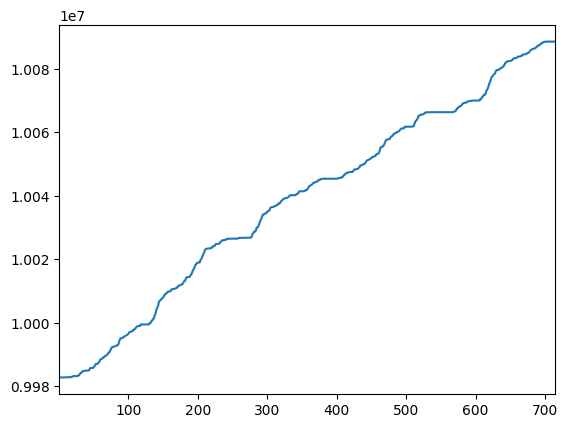

In [12]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,4])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],' -> ',x_axis[i],y_axis[i],raw_data_[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.xlim(1,715)
plt.plot(x_axis,y_axis)

Raw data filtered between 02-07-2026 05:00 and 04-07-2026 05:00